**1. Setup Awal & Pengecekan Versi**

In [2]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

print("Versi Python dan Scikit-Learn sudah sesuai!")

Versi Python dan Scikit-Learn sudah sesuai!


 2. Mengunduh Data


In [3]:
import os
import urllib.request

# Menentukan alamat URL utama dan folder untuk menyimpan data
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
datapath = os.path.join("datasets", "lifesat", "")

# Membuat direktori (folder) jika belum ada
os.makedirs(datapath, exist_ok=True)

# Looping untuk mengunduh kedua file
for filename in ("oecd_bli_2015.csv", "gdp_per_capita.csv"):
    print("Downloading", filename)
    url = DOWNLOAD_ROOT + "datasets/lifesat/" + filename
    urllib.request.urlretrieve(url, datapath + filename)

print("\nDownload selesai!")


Download selesai!


3. Mempersiapkan & Menggabungkan Data

In [4]:
import pandas as pd

# Fungsi untuk membersihkan dan menggabungkan data
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

# Memuat data dari file CSV yang sudah diunduh
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv(datapath + "gdp_per_capita.csv", thousands=',', delimiter='\t',
                             encoding='latin1', na_values="n/a")

# Memanggil fungsi untuk mempersiapkan data
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)

# Menampilkan 5 baris pertama dari data yang sudah bersih
print("Data setelah dibersihkan dan digabungkan:")
country_stats.head()

Data setelah dibersihkan dan digabungkan:


,GDP per capita,Life satisfaction
Country,,
Russia,9054.914,6.0
Turkey,9437.372,5.6
Hungary,12239.894,4.9
Poland,12495.334,5.8
Slovak Republic,15991.736,6.1


4. Memvisualisasikan Data

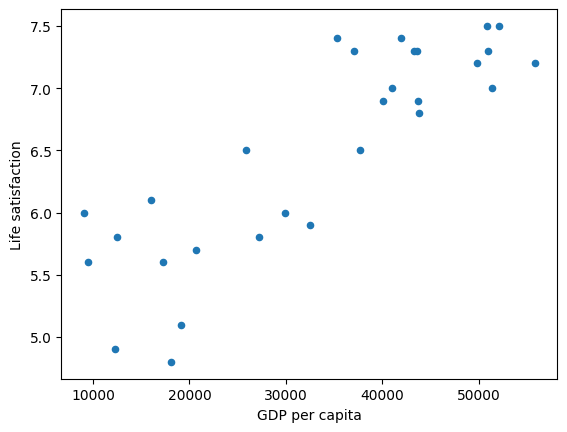

In [5]:
import matplotlib.pyplot as plt

# Membuat scatter plot
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

5. Melatih Model Machine Learning (Regresi Linier)

In [6]:
import numpy as np
import sklearn.linear_model

# Memisahkan fitur (X) dan target (y)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

# Memilih model Regresi Linier
model = sklearn.linear_model.LinearRegression()

# Melatih model dengan data
model.fit(X, y)

print("Model Regresi Linier berhasil dilatih!")

Model Regresi Linier berhasil dilatih!


6. Membuat Prediksi

In [7]:
# Data baru yang akan diprediksi (PDB per kapita Siprus)
X_new = [[22587]]

# Melakukan prediksi dengan model yang sudah dilatih
prediksi = model.predict(X_new)

print("Prediksi tingkat kepuasan hidup untuk Siprus:")
print(prediksi)

Prediksi tingkat kepuasan hidup untuk Siprus:
[[5.96242338]]


7. Mencoba Model Lain (k-Nearest Neighbors)

In [8]:
import sklearn.neighbors

# Memilih model k-Nearest Neighbors dengan k=3
model_knn = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)

# Melatih model KNN
model_knn.fit(X, y)

# Melakukan prediksi untuk Siprus dengan model KNN
prediksi_knn = model_knn.predict(X_new)

print("Prediksi tingkat kepuasan hidup untuk Siprus dengan KNN:")
print(prediksi_knn)

Prediksi tingkat kepuasan hidup untuk Siprus dengan KNN:
[[5.76666667]]


Berikut adalah penjelasan untuk setiap bagian kode:

Bagian 1: Setup Awal & Pengecekan Versi
Langkah ini penting untuk memastikan lingkungan kerja (environment) di Colab Anda memiliki versi Python (≥ 3.5) dan Scikit-Learn (≥ 0.20) yang sesuai. assert akan menghentikan program jika kondisinya tidak terpenuhi, sehingga kita tahu jika ada masalah kompatibilitas.

Bagian 2: Mengunduh Data
Kode ini secara otomatis mengunduh dua file data (.csv) dari repositori online (GitHub). Data ini adalah bahan bakar untuk model machine learning kita. os.makedirs(datapath, exist_ok=True) berfungsi untuk membuat folder tempat menyimpan data jika folder tersebut belum ada.

Bagian 3: Mempersiapkan & Menggabungkan Data
Data mentah jarang sekali bisa langsung dipakai. Bagian ini melakukan beberapa langkah penting menggunakan library pandas:

pd.read_csv(): Memuat data dari file CSV ke dalam struktur data yang mudah diolah bernama DataFrame.

prepare_country_stats: Ini adalah fungsi khusus yang dibuat untuk membersihkan dan menggabungkan kedua DataFrame tersebut. Fungsi ini menyatukan data PDB dan kepuasan hidup berdasarkan nama negara, lalu membuang beberapa data yang tidak relevan (outlier).

.head(): Perintah untuk menampilkan 5 baris pertama dari data yang sudah bersih agar kita bisa memeriksanya.

Bagian 4: Memvisualisasikan Data
Langkah ini sangat krusial dalam analisis data. Dengan membuat scatter plot (diagram tebar), kita bisa melihat hubungan visual antara PDB per kapita (sumbu x) dengan Tingkat Kepuasan Hidup (sumbu y). Dari grafik ini, terlihat ada tren positif (garis yang cenderung naik), yang mengindikasikan bahwa model linier mungkin cocok untuk data ini.

Bagian 5: Melatih Model Machine Learning (Regresi Linier)
Ini adalah inti dari proses machine learning.

Pemisahan Fitur dan Target: Kita memisahkan data menjadi X (fitur input, yaitu PDB per kapita) dan y (target output yang ingin diprediksi, yaitu kepuasan hidup).

Pemilihan Model: Kita memilih LinearRegression, sebuah model sederhana yang tujuannya adalah menemukan satu garis lurus yang paling "pas" atau paling mendekati semua titik data.

Pelatihan (fit): Metode .fit(X, y) adalah proses "belajar". Model akan menganalisis data dan secara otomatis menghitung parameter terbaik (kemiringan dan titik potong) untuk garis lurus tersebut.

Bagian 6: Membuat Prediksi
Setelah model "pintar", kita bisa mengujinya. Kita membuat data baru, X_new, yang berisi PDB per kapita negara Siprus. Dengan menggunakan metode .predict(X_new), model akan menggunakan garis lurus yang telah dipelajarinya untuk menghitung dan memberikan prediksi tingkat kepuasan hidup untuk PDB tersebut.

Bagian 7: Mencoba Model Lain (k-Nearest Neighbors)
Bagian ini menunjukkan fleksibilitas Scikit-Learn. Kita mencoba model yang berbeda, yaitu KNeighborsRegressor. Cara kerjanya berbeda: untuk memprediksi nilai Siprus, model ini akan mencari 3 (n_neighbors=3) negara terdekat di data latih berdasarkan PDB-nya, lalu mengambil rata-rata dari tingkat kepuasan hidup ketiga negara tersebut sebagai hasil prediksi. Ini menunjukkan bahwa model yang berbeda dapat memberikan hasil yang berbeda pula.